In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# paths and constants
DATA_DIR = Path('../data/keypoints_1')
OUT_DIR = Path('../data/processed')
LABELS_CSV = Path('../data/hp.csv')
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Load Data

In [3]:
def load_labels_mapping():
    if not LABELS_CSV.exists():
        print(f"Warning: {LABELS_CSV} not found")
        return None
    
    labels_df = pd.read_csv(LABELS_CSV)
    mapping = {}
    for _, row in labels_df.iterrows():
        video_name = f"{row['division']}_{row['id']}"
        mapping[video_name] = row['labels']
    return mapping

In [4]:
def find_videos(root=DATA_DIR):
    records = []
    if not root.exists():
        raise FileNotFoundError(f"Data dir not found: {root}")
    
    labels_mapping = load_labels_mapping()
    
    for label_dir in sorted(root.iterdir()):
        if not label_dir.is_dir():
            continue
        division = label_dir.name
        
        for video_dir in sorted(label_dir.iterdir()):
            if not video_dir.is_dir():
                continue
            
            np_path = video_dir / 'keypoints.npy'
            json_path = video_dir / 'keypoints.json'
            if not np_path.exists():
                continue
            
            video_name = video_dir.name
            trick_label = labels_mapping.get(video_name, division) if labels_mapping else division
            
            records.append({
                'label': trick_label,
                'division': division,
                'video': video_name,
                'np_path': np_path,
                'json_path': json_path
            })
    
    return pd.DataFrame(records)

In [5]:
def load_keypoints(np_path: Path):
    arr = np.load(np_path)
    if arr.ndim != 3: 
        raise ValueError(f"Unexpected shape {np_path}: {arr.shape}")
    return arr.astype(np.float32)

## Preprocessing Functions

In [6]:
def interpolate_missing(arr, visibility_threshold=0.1):
    # fill in missing keypoints using interpolation
    out = arr.copy()
    T = out.shape[0]
    
    for lm in range(out.shape[1]):
        vis = out[:, lm, 3]
        bad = vis < visibility_threshold
        if bad.all():
            continue
        
        for d in range(3):
            vals = out[:, lm, d].astype(float)
            vals[bad] = np.nan
            s = pd.Series(vals)
            vals_filled = s.interpolate(limit_direction='both').bfill().ffill().values
            out[:, lm, d] = vals_filled.astype(np.float32)
    
    return out

In [7]:
def torso_scale_single(lm):
    # get torso length for normalization
    left_sh = lm[11][:2]
    right_sh = lm[12][:2]
    left_hip = lm[23][:2]
    right_hip = lm[24][:2]
    mid_sh = (left_sh + right_sh) / 2.0
    mid_hip = (left_hip + right_hip) / 2.0
    d = np.linalg.norm(mid_sh - mid_hip)
    return max(d, 1e-6)

In [8]:
def normalize_by_torso(arr):
    # normalize positions relative to hip center and torso length
    out = arr.copy()
    for t in range(out.shape[0]):
        lm = out[t]
        hip_center = (lm[23][:2] + lm[24][:2]) / 2.0
        scale = torso_scale_single(lm)
        out[t, :, :2] = (lm[:, :2] - hip_center) / scale
    return out

In [9]:
def pad_or_truncate(arr, target_len=64, strategy='center'):
    T = arr.shape[0]
    if T == target_len:
        return arr
    if T > target_len:
        if strategy == 'center':
            start = max(0, (T - target_len) // 2)
            return arr[start:start+target_len]
        return arr[:target_len]
    
    pad = np.zeros((target_len - T, arr.shape[1], arr.shape[2]), dtype=arr.dtype)
    return np.concatenate([arr, pad], axis=0)

In [10]:
def angle_at(a, b, c):
    # compute angle at point b formed by points a-b-c
    ba = a - b
    bc = c - b
    lena = np.linalg.norm(ba)
    lenb = np.linalg.norm(bc)
    if lena < 1e-6 or lenb < 1e-6:
        return 0.0
    cosang = np.dot(ba, bc) / (lena * lenb)
    cosang = np.clip(cosang, -1.0, 1.0)
    return math.acos(cosang)

## Feature Extraction

In [11]:
ANGLE_TRIPLETS = [(11, 13, 15), (12, 14, 16), (23, 25, 27), (24, 26, 28)]
def compute_frame_features(seq):
    # extract features from keypoint sequence
    T = seq.shape[0]
    flat = seq[:, :, :3].reshape(T, -1)
    
    # joint angles
    angles = np.zeros((T, len(ANGLE_TRIPLETS)), dtype=np.float32)
    for t in range(T):
        for i, (a, b, c) in enumerate(ANGLE_TRIPLETS):
            angles[t, i] = angle_at(seq[t, a, :2], seq[t, b, :2], seq[t, c, :2])
    
    # pairwise distances between key joints
    important = [11, 12, 23, 24, 13, 14, 25, 26]
    pdists = []
    for t in range(T):
        coords = seq[t, important, :2]
        dists = []
        for i in range(coords.shape[0]):
            for j in range(i+1, coords.shape[0]):
                dists.append(np.linalg.norm(coords[i] - coords[j]))
        pdists.append(dists)
    pdists = np.array(pdists)
    
    # velocity
    vel = np.vstack((np.zeros((1, flat.shape[1])), np.diff(flat, axis=0)))
    
    feats = np.concatenate([flat, angles, pdists, vel], axis=1)
    return feats

In [12]:
def aggregate_video_features(seq, target_len=64):
    # preprocess and aggregate features for entire video
    seq = interpolate_missing(seq)
    seq = normalize_by_torso(seq)
    seq = pad_or_truncate(seq, target_len=target_len)
    
    frame_feats = compute_frame_features(seq)
    mean = frame_feats.mean(axis=0)
    std = frame_feats.std(axis=0)
    
    return np.concatenate([mean, std])

In [13]:
def build_aggregated_dataset(index_df, sample_limit=None, target_len=64):
    rows = []
    X = []
    y = []
    
    subset = index_df.sample(min(len(index_df), sample_limit), random_state=0) if sample_limit is not None else index_df
    
    for _, r in subset.iterrows():
        seq = load_keypoints(r['np_path'])
        vec = aggregate_video_features(seq, target_len=target_len)
        X.append(vec)
        y.append(r['label'])
        rows.append({
            'label': r['label'],
            'division': r.get('division', ''),
            'video': r['video'],
            'np_path': str(r['np_path'])
        })
    
    return np.array(X), np.array(y), pd.DataFrame(rows)

In [14]:
def do_dimensionality_reduction(X, n_pca=10):
    n_samples, n_features = X.shape
    print(f'Running PCA -> t-SNE (n_samples={n_samples}, n_features={n_features})...')

    pca_components = max(2, min(n_pca, n_samples, n_features))
    pca = PCA(n_components=pca_components, random_state=0)
    X_pca = pca.fit_transform(X)

    if n_samples < 3:
        print('Too few samples for t-SNE (need >=3). Returning PCA only.')
        return {'pca': X_pca}

    perplexity = min(30, max(2, (n_samples - 1) // 3))
    perplexity = min(perplexity, n_samples - 1)
    
    try:
        tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate='auto', init='pca', random_state=0)
        X_tsne = tsne.fit_transform(X_pca[:, :pca_components])
    except Exception as exc:
        print('t-SNE failed:', exc)
        X_tsne = None
    
    return {'pca': X_pca, 'tsne': X_tsne}

## Run Analysis

In [15]:
# load videos
df = find_videos()
print(f'Found {len(df)} videos\n')
print('Label distribution:')
print(df['label'].value_counts())

Found 19 videos

Label distribution:
label
sugar_push    10
sugar_tag      9
Name: count, dtype: int64


In [16]:
# build dataset
X, y, meta = build_aggregated_dataset(df, target_len=64)

# Filter for target classes only
target_classes = ['sugar_push', 'sugar_tag']
mask = np.isin(y, target_classes)
X = X[mask]
y = y[mask]
meta = meta[mask].reset_index(drop=True)

print(f'Filtered Dataset shape: {X.shape}')

# standardize
Xs = StandardScaler().fit_transform(X)


Filtered Dataset shape: (19, 460)


In [17]:
# dimensionality reduction
emb = do_dimensionality_reduction(X)

if 'tsne' in emb and emb['tsne'] is not None:
    emb_plot = emb['tsne']
    method = 't-SNE'
else:
    emb_plot = emb['pca'][:, :2]
    method = 'PCA'

print(f'Using {method} for visualization')

Running PCA -> t-SNE (n_samples=19, n_features=460)...
Using t-SNE for visualization


### Visualization 1: By Trick Type

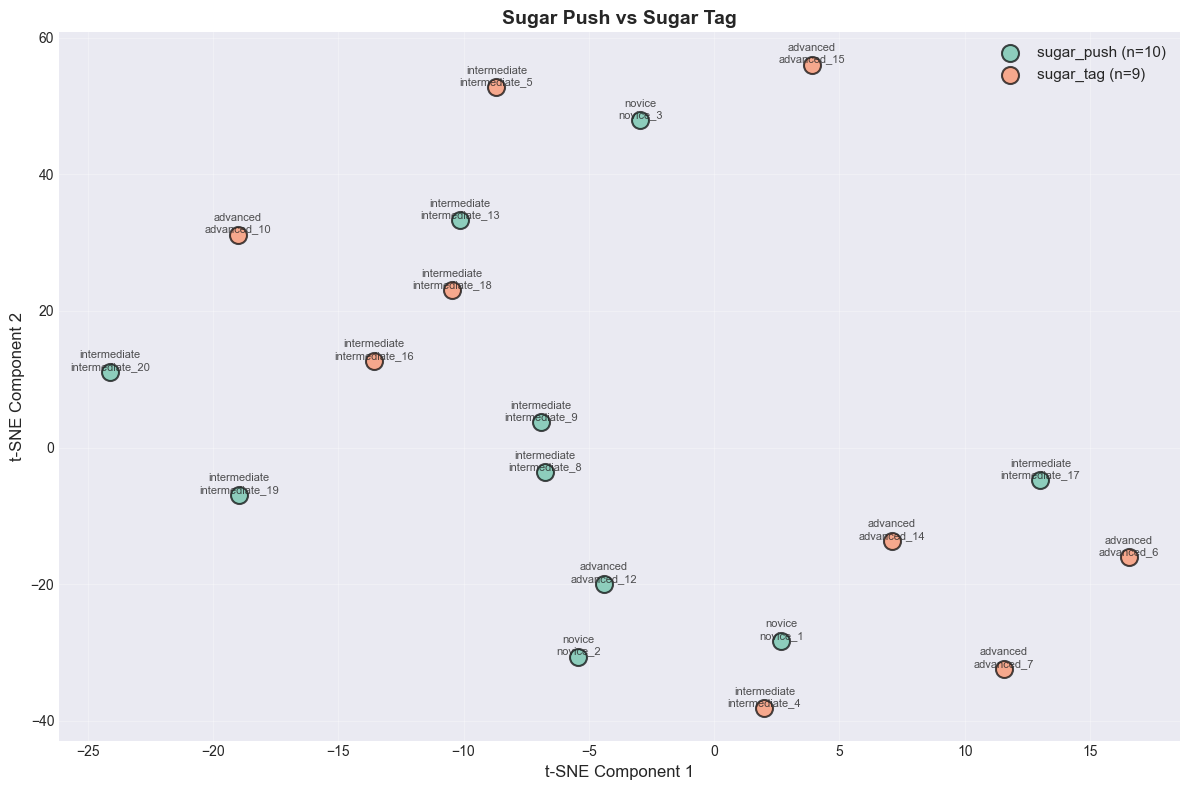

In [18]:
# plot by trick label
plt.figure(figsize=(12, 8))
unique_labels = np.unique(y)
colors = sns.color_palette('Set2', n_colors=len(unique_labels))
label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

for label in unique_labels:
    mask = y == label
    indices = np.where(mask)[0]
    
    plt.scatter(
        emb_plot[mask, 0],
        emb_plot[mask, 1],
        label=f'{label} (n={mask.sum()})',
        s=150,
        alpha=0.7,
        color=label_to_color[label],
        edgecolors='black',
        linewidth=1.5
    )
    
    for idx in indices:
        division = meta.iloc[idx]['division']
        video = meta.iloc[idx]['video']
        plt.annotate(
            f"{division}\n{video}",
            (emb_plot[idx, 0], emb_plot[idx, 1]),
            fontsize=8,
            alpha=0.8,
            ha='center',
            va='bottom'
        )

plt.xlabel(f'{method} Component 1', fontsize=12)
plt.ylabel(f'{method} Component 2', fontsize=12)
plt.title('Sugar Push vs Sugar Tag', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### KNN Classification

In [19]:
# Split data into train and test sets
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    Xs, y, np.arange(len(y)), test_size=0.2, random_state=17, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Train Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Evaluate
y_pred = dt.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nDecision Tree Accuracy: {acc:.2%}")


Training samples: 15
Testing samples: 4

Decision Tree Accuracy: 100.00%


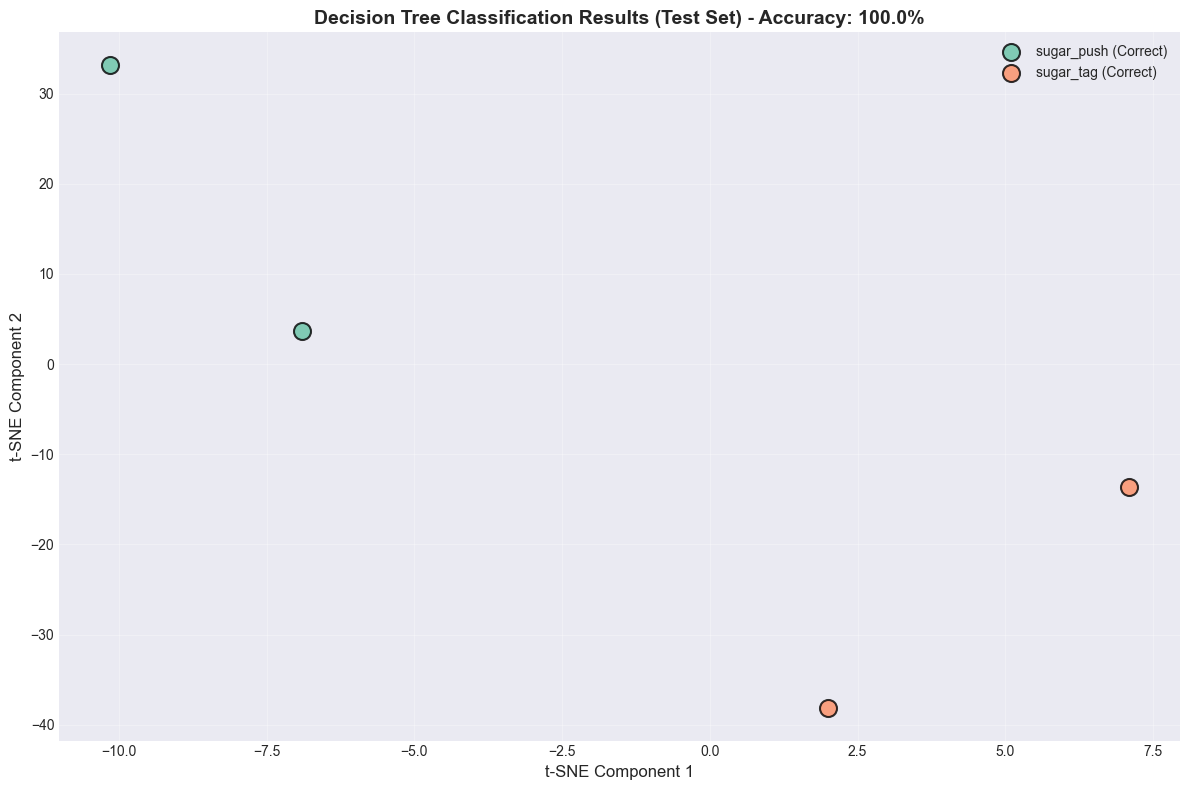

In [20]:
# Visualize KNN Results on Test Set
plt.figure(figsize=(12, 8))

# Get the 2D embedding for test samples
emb_test = emb_plot[idx_test]

# Color by prediction correctness
unique_classes = np.unique(y)
colors = sns.color_palette('Set2', n_colors=len(unique_classes))
class_to_color = {cls: colors[i] for i, cls in enumerate(unique_classes)}

correct_mask = y_pred == y_test

for cls in unique_classes:
    # Plot correct predictions for this class
    mask = (y_test == cls) & correct_mask
    if mask.any():
        plt.scatter(emb_test[mask, 0], emb_test[mask, 1], 
                   c=[class_to_color[cls]], label=f'{cls} (Correct)',
                   s=150, alpha=0.8, edgecolors='black', marker='o', linewidth=1.5)
    
    # Plot incorrect predictions (misclassified)
    mask_err = (y_test == cls) & ~correct_mask
    if mask_err.any():
        plt.scatter(emb_test[mask_err, 0], emb_test[mask_err, 1], 
                   c=[class_to_color[cls]], label=f'{cls} (Misclassified)',
                   s=200, alpha=0.9, edgecolors='red', linewidth=3, marker='X')

plt.title(f'Decision Tree Classification Results (Test Set) - Accuracy: {acc:.1%}', fontsize=14, fontweight='bold')
plt.xlabel(f'{method} Component 1', fontsize=12)
plt.ylabel(f'{method} Component 2', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Output a Model

In [21]:
# Create a full Decision Tree pipeline for deployment
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10, random_state=0)),
    ("dt", DecisionTreeClassifier(random_state=42))
])

# Fit on ALL data for the final model
pipe.fit(X, y)

# Save model
model_path = OUT_DIR / 'decision_tree_classifier.joblib'
joblib.dump(pipe, model_path)
print(f"Saved Decision Tree model to {model_path}")


Saved Decision Tree model to ../data/processed/decision_tree_classifier.joblib


## Predict

In [22]:
# Load saved Decision Tree model
model_path = Path("../data/processed/decision_tree_classifier.joblib")
pipe = joblib.load(model_path)

# Load a sample video for prediction
test_path = Path("../data/keypoints_2/advanced/advanced_9/keypoints.npy") 

print(f"Testing on: {test_path}")
seq = load_keypoints(test_path)
vec = aggregate_video_features(seq, target_len=64)

# Predict with Decision Tree
prediction = pipe.predict([vec])[0]
probs = pipe.predict_proba([vec])[0]
class_labels = pipe.classes_

print(f"\nPredicted Class: {prediction}")
print("\nClass Probabilities:")
for lbl, prob in zip(class_labels, probs):
    print(f"  {lbl}: {prob:.2%}")


Testing on: ../data/keypoints_2/advanced/advanced_9/keypoints.npy

Predicted Class: sugar_push

Class Probabilities:
  sugar_push: 100.00%
  sugar_tag: 0.00%
